In [1]:
import numpy as np
import pandas as pd

In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 96% 151M/157M [00:00<00:00, 1.58GB/s]
100% 157M/157M [00:00<00:00, 1.56GB/s]


In [4]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [5]:
import tensorflow as tf
from tensorflow import keras
from  keras import Sequential
from keras.layers import Dropout,MaxPooling2D,Conv2D,Dense,BatchNormalization,Flatten
from keras.applications.resnet import ResNet50

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'Training',
    labels='inferred',
    subset="training",
    seed=123,
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    'Testing',
    labels='inferred',
    subset="validation",
    seed=123,
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2
)



Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [7]:
def process(image,label):
  image = tf.cast(image/255.,tf.float32)
  return image,label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

# Model Building

Calling in Resnet and applying data sugmentation,early stopping

1. Feature Extraction

Using RESNet

In [ ]:
from keras.applications.vgg16 import VGG16

In [8]:
conv_base = ResNet50(
    weights='imagenet',
    input_shape =(256,256,3),
    include_top = False
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
from keras.layers import RandomFlip,RandomZoom,RandomContrast
data_aug = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomZoom(0.1),
    RandomContrast(0.1)
])


In [10]:
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dropout
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [11]:
from keras.layers import GlobalAveragePooling2D

In [18]:
set_trainable = False

# for layer in conv_base.layers:
#   if layer.name == 'block5_conv1':
#     set_trainable = True
#   if set_trainable:
#     layer.trainable = True
#   else:
#     layer.trainable = False

for layer in conv_base.layers:
    if "conv4" in layer.name or "conv5" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer False
conv1_pad False
conv1_conv False
conv1_bn False
conv1_relu False
pool1_pad False
pool1_pool False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False
conv2_block1_2_conv False
conv2_block1_2_bn False
conv2_block1_2_relu False
conv2_block1_0_conv False
conv2_block1_3_conv False
conv2_block1_0_bn False
conv2_block1_3_bn False
conv2_block1_add False
conv2_block1_out False
conv2_block2_1_conv False
conv2_block2_1_bn False
conv2_block2_1_relu False
conv2_block2_2_conv False
conv2_block2_2_bn False
conv2_block2_2_relu False
conv2_block2_3_conv False
conv2_block2_3_bn False
conv2_block2_add False
conv2_block2_out False
conv2_block3_1_conv False
conv2_block3_1_bn False
conv2_block3_1_relu False
conv2_block3_2_conv False
conv2_block3_2_bn False
conv2_block3_2_relu False
conv2_block3_3_conv False
conv2_block3_3_bn False
conv2_block3_add False
conv2_block3_out False
conv3_block1_1_conv False
conv3_block1_1_bn False
conv3_block1_1_relu False
conv3_block1_2

In [24]:
# making our model wiht the conv_base
model = Sequential()
model.add(tf.keras.layers.Input(shape=(256,256,3)))
model.add(data_aug)
model.add(conv_base)
model.add(GlobalAveragePooling2D())
# model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4,activation='softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 22,610,180 (86.25 MB)

 Non-trainable params: 1,503,104 (5.73 MB)

In [26]:
from tensorflow.keras.optimizers import Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(loss = "sparse_categorical_crossentropy",optimizer=optimizer,metrics=['accuracy'])

In [22]:
history = model.fit(train_ds,validation_data=test_ds,epochs=20,callbacks=[early_stop])

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 396ms/step - accuracy: 0.6339 - loss: 0.9036 - val_accuracy: 0.2937 - val_loss: 1.3579
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - accuracy: 0.7417 - loss: 0.6429 - val_accuracy: 0.6094 - val_loss: 0.9615
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 379ms/step - accuracy: 0.7926 - loss: 0.5368 - val_accuracy: 0.7156 - val_loss: 0.7021
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 381ms/step - accuracy: 0.8275 - loss: 0.4490 - val_accuracy: 0.7344 - val_loss: 0.7029
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 378ms/step - accuracy: 0.8574 - loss: 0.3806 - val_accuracy: 0.7906 - val_loss: 0.6135
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 378ms/step - accuracy: 0.8750 - loss: 0.3352 - val_accuracy: 0.8062 - val_loss: 0.6112
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 377ms/step - accuracy: 0.8917 - loss: 0.2873 - val_accuracy: 0.7937 - val_loss: 0.6654
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 377ms/step - accuracy: 0.9069 - loss: 0

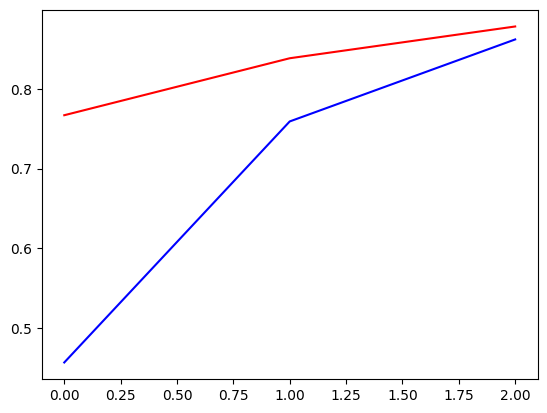

In [36]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='Train')
plt.plot(history.history['val_accuracy'],color='blue',label='Val')

Using VGGNET

In [29]:
from keras.applications.vgg16 import VGG16
conv_base = VGG16(
    weights='imagenet',
    input_shape =(256,256,3),
    include_top = False
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
from keras.layers import RandomFlip,RandomZoom,RandomContrast
data_aug = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomZoom(0.1),
    RandomContrast(0.1)
])


In [31]:
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import GlobalAveragePooling2D
from keras.layers import Dropout
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [32]:
set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False


for layer in conv_base.layers:
  print(layer.name,layer.trainable)

In [34]:
# making our model wiht the conv_base
model = Sequential()
model.add(tf.keras.layers.Input(shape=(256,256,3)))
model.add(data_aug)
model.add(conv_base)
# model.add(GlobalAveragePooling2D())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4,activation='softmax'))
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,104,580 (88.14 MB)

 Trainable params: 15,469,316 (59.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [35]:
from tensorflow.keras.optimizers import Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(loss = "sparse_categorical_crossentropy",optimizer=optimizer,metrics=['accuracy'])

In [37]:
history2 = model.fit(train_ds,validation_data=test_ds,epochs=20,callbacks=[early_stop])

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 253ms/step - accuracy: 0.7964 - loss: 0.5355 - val_accuracy: 0.8156 - val_loss: 0.6025
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.9129 - loss: 0.2429 - val_accuracy: 0.8781 - val_loss: 0.4875
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 238ms/step - accuracy: 0.9471 - loss: 0.1518 - val_accuracy: 0.9375 - val_loss: 0.4059
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 244ms/step - accuracy: 0.9603 - loss: 0.1190 - val_accuracy: 0.9031 - val_loss: 0.5192
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.9694 - loss: 0.0849 - val_accuracy: 0.9281 - val_loss: 0.4997
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 238ms/step - accuracy: 0.9703 - loss: 0.0767 - val_accuracy: 0.9281 - val_loss: 0.5176


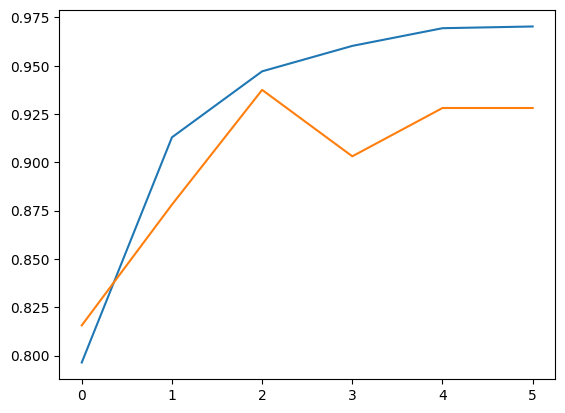

In [38]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])